In [1]:
from sliced_rag import hotpot_score
import json

In [13]:
import importlib
importlib.reload(hotpot_score)

<module 'sliced_rag.hotpot_score' from 'C:\\Users\\Lucas\\Projects\\SlicedRAG\\src\\sliced_rag\\hotpot_score.py'>

In [ ]:
dataset = "wikitext2"
sparsities = [0.0, 0.1, 0.25, 0.4, 0.6]
model_id = "Qwen2-1.5B-Instruct"

hotpot_dataset_path = "../data/hotpot/dataset/hotpot_dev_distractor_v1.json"

In [14]:
def filter_gold_set(prediction_file, full_gold_file, out_file):
    with open(prediction_file) as f:
        predictions = json.load(f)
    
    with open(full_gold_file) as f:
        full_gold = json.load(f)

    predicted_ids = set()
    if "answer" in predictions:
        predicted_ids.update(predictions["answer"].keys())

    filtered_gold = [instance for instance in full_gold if instance["_id"] in predicted_ids]

    # print(f"Original gold set size: {len(full_gold)}")
    # print(f"Predicted IDs count: {len(predicted_ids)}")
    # print(f"Filtered gold set size: {len(filtered_gold)}")

    with open(out_file, "w", encoding="utf-8") as f:
        json.dump(filtered_gold, f, indent=2)

    print(f"Filtered gold set saved to {out_file}")

In [17]:
datasets = ["wikitext2", "squad", "hotpotqa", "coqa"]
sparsities = [0.0, 0.1, 0.25, 0.4, 0.6]

results = {}

for dataset in datasets:
    for sparsity in sparsities:
        predictions_path = f"../data/hotpot/{model_id}_{dataset}_s{sparsity:.2f}_lim1000.json"

        filter_gold_set(
            predictions_path,
            hotpot_dataset_path,
            "../data/temp.json"
        )

        result = hotpot_score.eval(predictions_path, "../data/temp.json")
        results[(dataset, sparsity)] = result

Filtered gold set saved to ../data/temp.json
{'em': 0.179, 'f1': 0.3208341920193834, 'prec': 0.30011674123882676, 'recall': 0.5049210317460314, 'sp_em': 0.0, 'sp_f1': 0.0, 'sp_prec': 0.0, 'sp_recall': 0.0, 'joint_em': 0.0, 'joint_f1': 0.0, 'joint_prec': 0.0, 'joint_recall': 0.0}
Filtered gold set saved to ../data/temp.json
{'em': 0.011, 'f1': 0.07600139025132752, 'prec': 0.054535235210025, 'recall': 0.4492932539682539, 'sp_em': 0.0, 'sp_f1': 0.0, 'sp_prec': 0.0, 'sp_recall': 0.0, 'joint_em': 0.0, 'joint_f1': 0.0, 'joint_prec': 0.0, 'joint_recall': 0.0}
Filtered gold set saved to ../data/temp.json
{'em': 0.0, 'f1': 0.0309021077810789, 'prec': 0.016891047891589243, 'recall': 0.254604365079365, 'sp_em': 0.0, 'sp_f1': 0.0, 'sp_prec': 0.0, 'sp_recall': 0.0, 'joint_em': 0.0, 'joint_f1': 0.0, 'joint_prec': 0.0, 'joint_recall': 0.0}
Filtered gold set saved to ../data/temp.json
{'em': 0.0, 'f1': 0.019817074501741996, 'prec': 0.010899311248923207, 'recall': 0.15131587301587304, 'sp_em': 0.0, 'sp

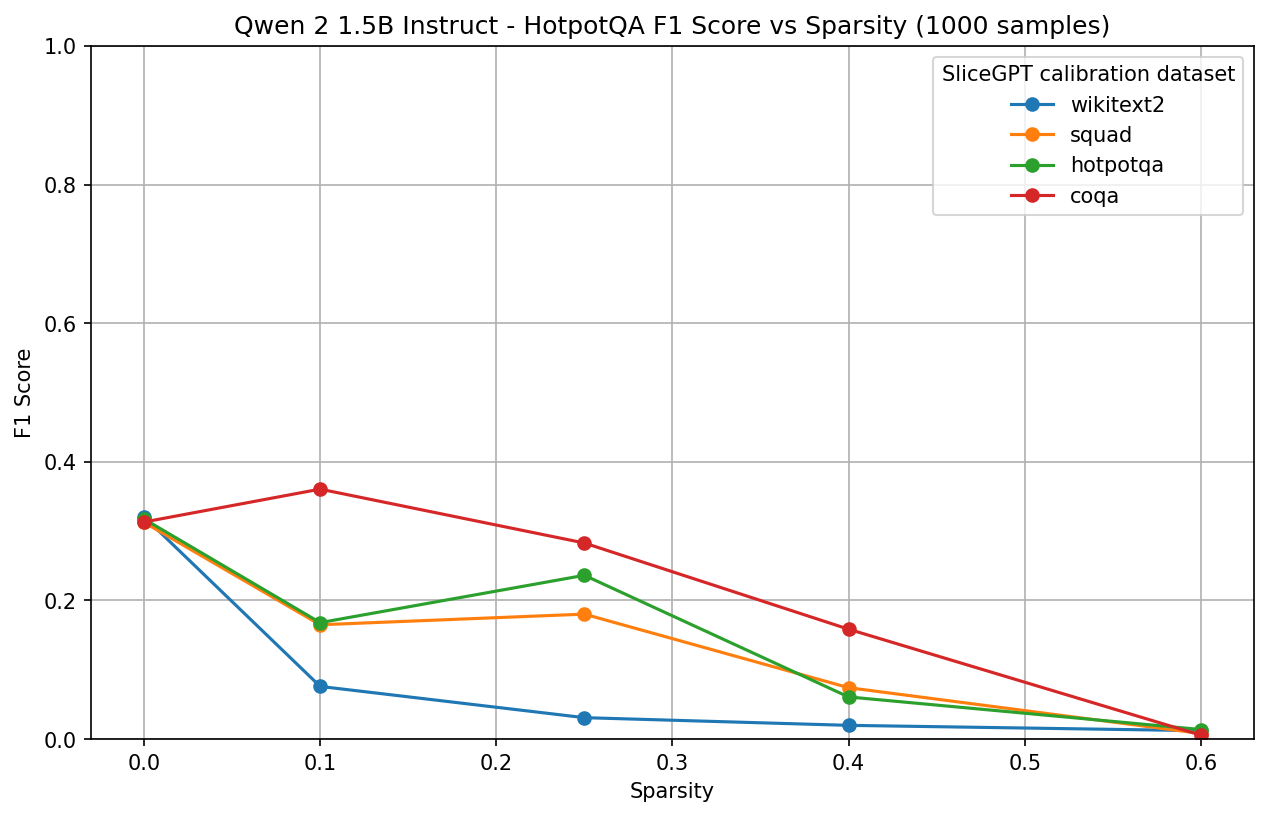

In [29]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150
plt.figure(figsize=(10, 6))
for dataset in datasets:
    f1_values = [results[(dataset, s)]['f1'] for s in sparsities]
    plt.plot(sparsities, f1_values, marker='o', label=dataset)
    plt.title('Qwen 2 1.5B Instruct - HotpotQA F1 Score vs Sparsity (1000 samples)')
    plt.xlabel('Sparsity')
    plt.ylabel('F1 Score')
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend(title="SliceGPT calibration dataset")
plt.show()

In [ ]:
predictions_path = f"../data/hotpot/{model_id}_baseline_lim1000.json"

filter_gold_set(
    predictions_path,
    hotpot_dataset_path,
    "../data/temp.json"
)

result = hotpot_score.eval(predictions_path, "../data/temp.json")

print(result)